# Scaling study

In [1]:
import sys; sys.path.insert(0, "../../..")
%load_ext autoreload
%autoreload 2

from functools import partial

from algorithms.CMIICAdapter import CMIICAdapter
from algorithms.CPCAdapter import CPCAdapter

from data.generators import generate_from_sem, generate_from_cbn_dag
from experiments.scaling.runner import ScalingRunner
from experiments.scaling.plot import plot_facet, METRIC_NAMES
from experiments.scaling.io import load_results

## Configuration

In [2]:
algo_configs = [
    ("CPC",   CPCAdapter,   {"alpha": 0.05, "max_conditioning_set_size": 3}),
    ("CMIIC", CMIICAdapter, {"alpha": 0.05}),
]

generator = partial(generate_from_cbn_dag, marginal_type="Uniform", lcc_types="NormalCopula")

runner = ScalingRunner(
    algo_configs=algo_configs,
    generator=generator,
    generator_name="cbn_unif_gauss",
    n_vars_list=[10, 20],
    n_samples_list=[200, 500, 1000, 3000, 5000],
    density=1.5,
    n_graphs=30,
    seed=42,
)

## Run

In [3]:
df = runner.run()

## (ou charger des résultats existants)

In [4]:
#df = load_results("results/2026-03-27_13h11_cbn_unif_mixture/results.csv")

## Visualisation

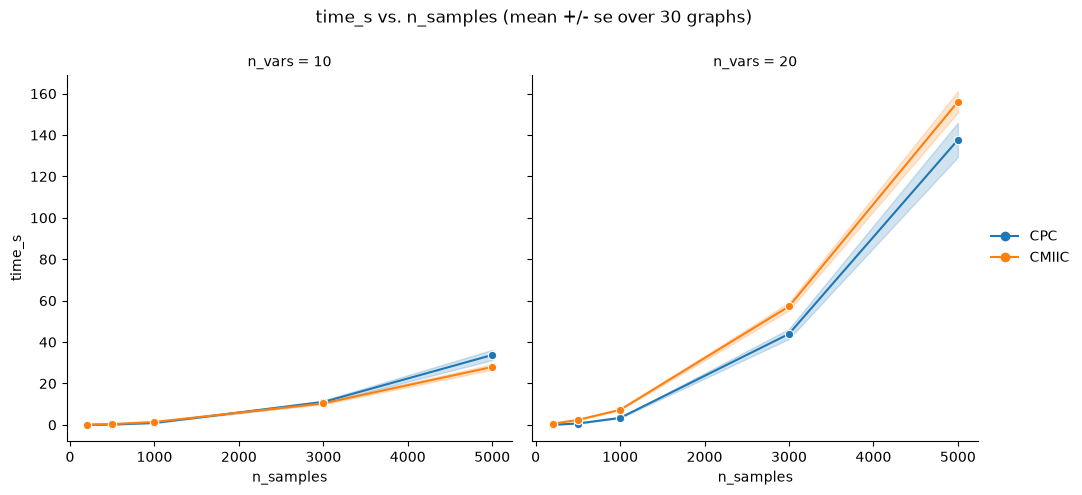

In [5]:
plot_facet(df, y="time_s", col="n_vars"); # Temps de calcul

## Métriques

### Sur les CPDAG

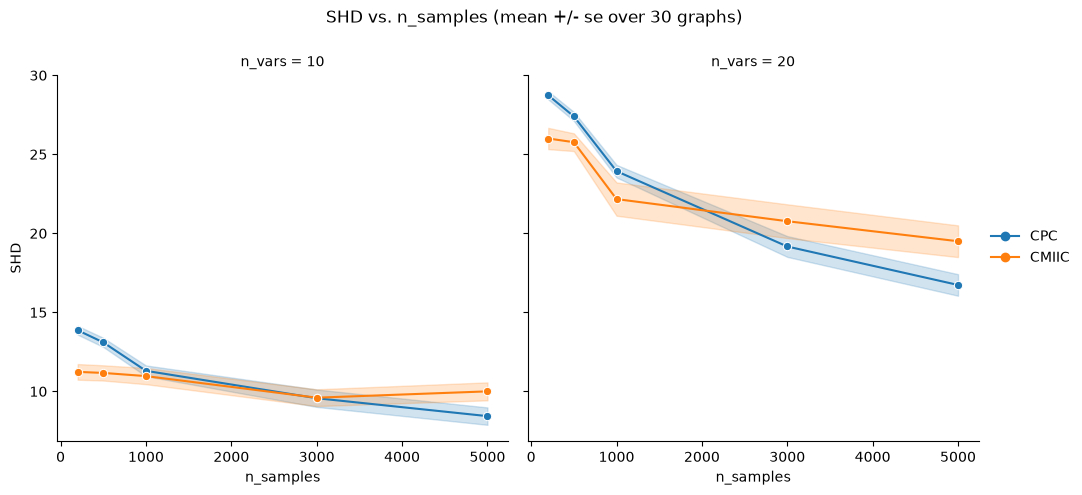

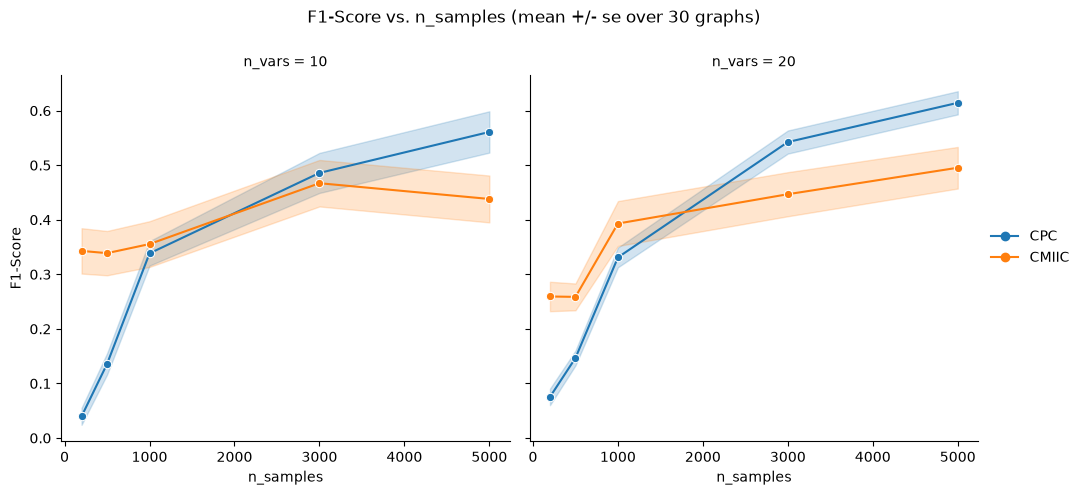

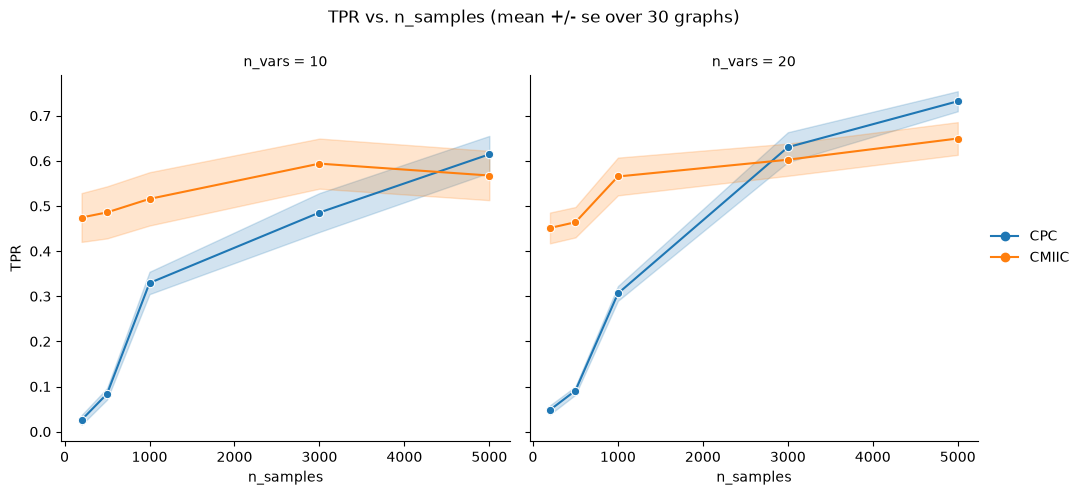

In [6]:
for metric in METRIC_NAMES:
    plot_facet(df, y=metric, col="n_vars");

### Sur les squelettes

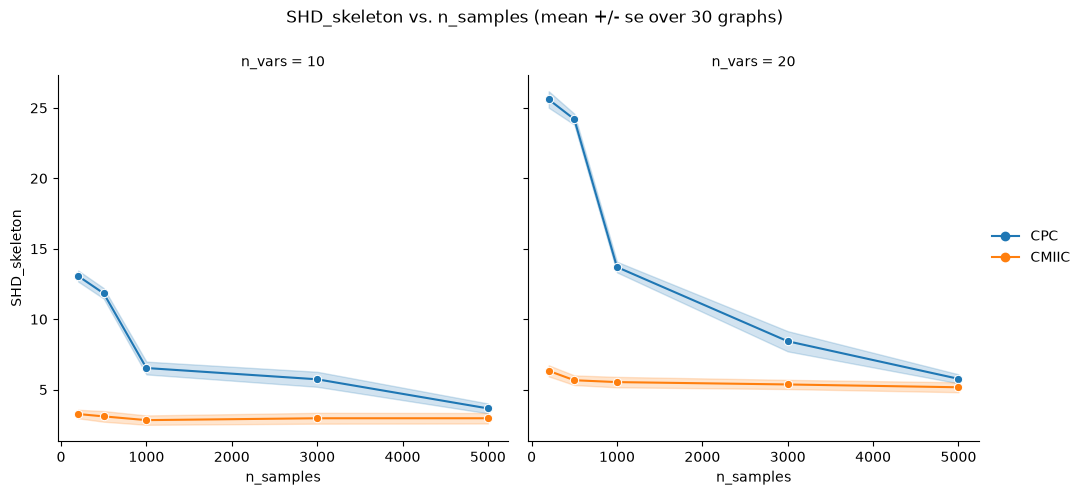

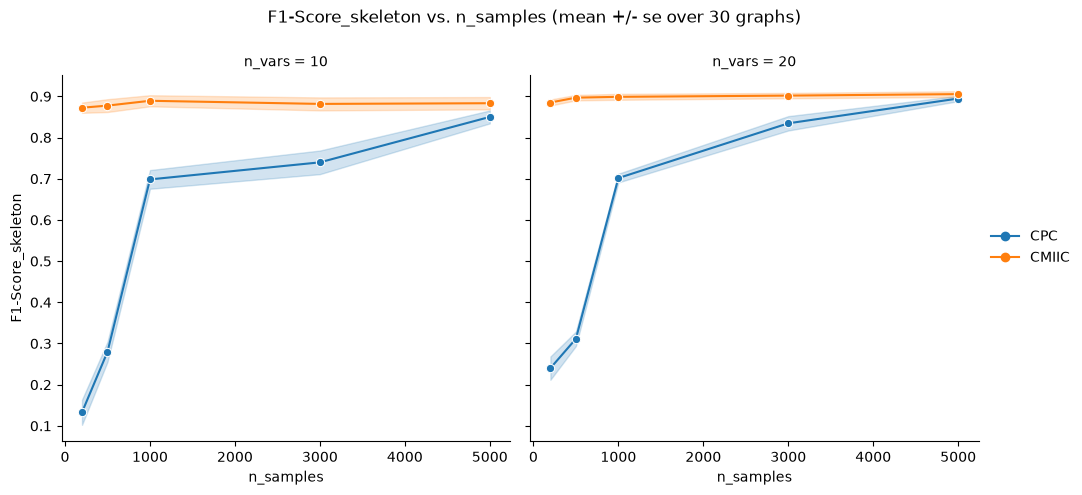

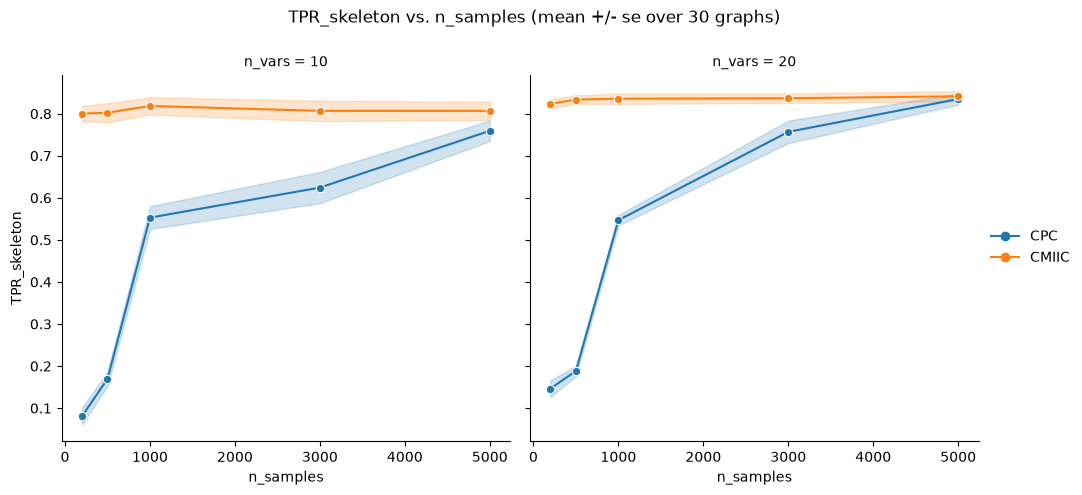

In [7]:
for metric in METRIC_NAMES:
    plot_facet(df, y=f"{metric}_skeleton", col="n_vars");